In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Data/date_time_train_cleaned.csv')

data

,YearBuilt,YearRemodAdd,YrSold,MoSold,SalePrice
0,2003,2003,2008,2,208500
1,1976,1976,2007,5,181500
2,2001,2002,2008,9,223500
3,1915,1970,2006,2,140000
4,2000,2000,2008,12,250000
...,...,...,...,...,...
1407,1999,2000,2007,8,175000
1408,1978,1988,2010,2,210000
1409,1941,2006,2010,5,266500
1410,1950,1996,2010,4,142125


## Correlation and MI score

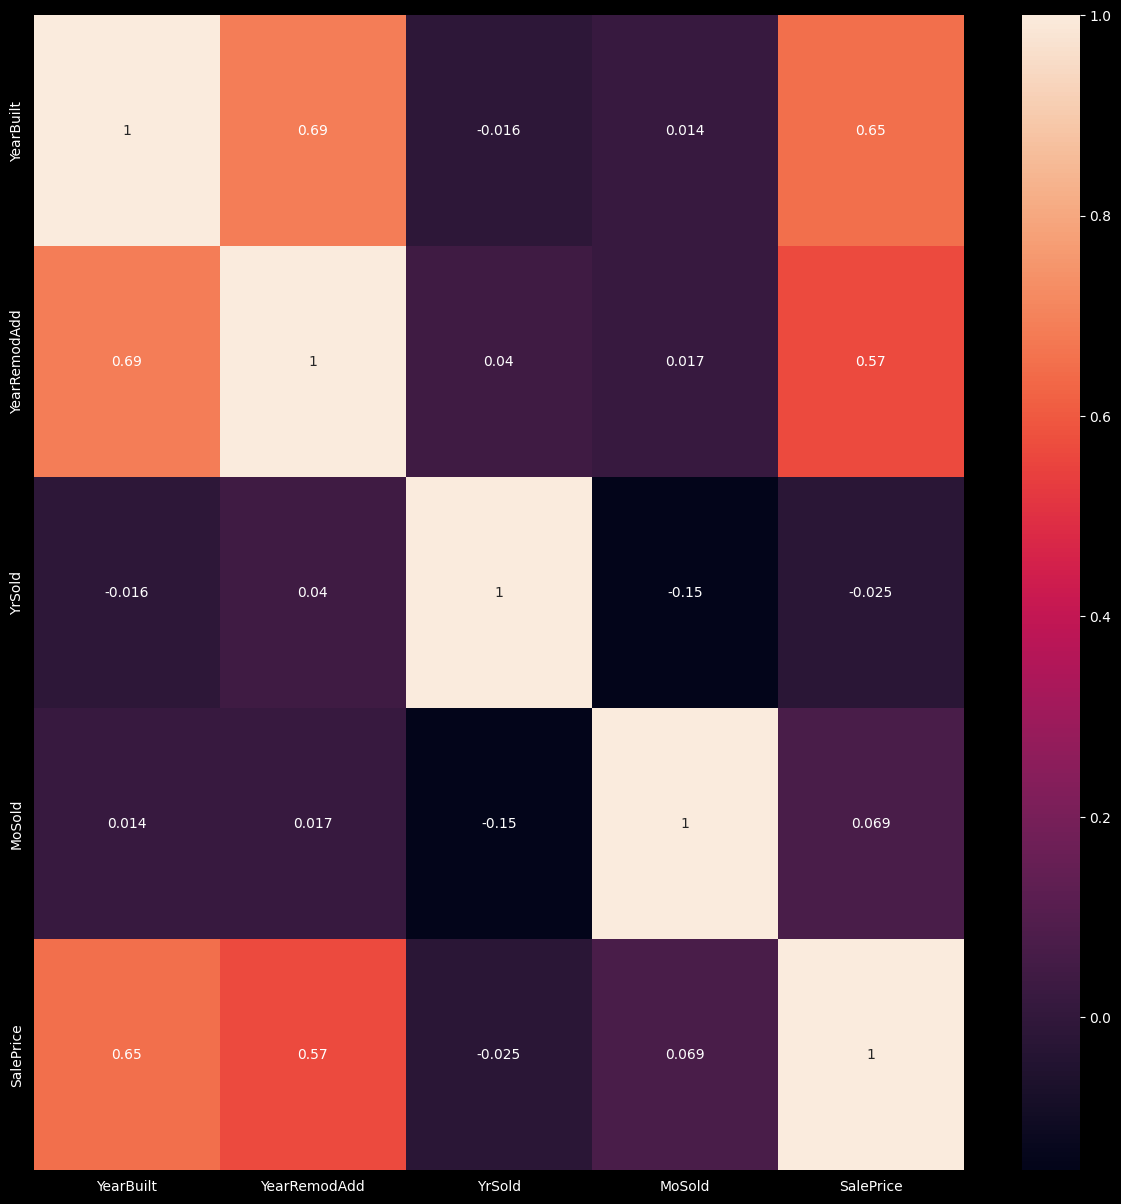

In [5]:
corr_mtx = data.corr(method='spearman')

plt.figure(figsize=(15,15))
sns.heatmap(corr_mtx, annot=True)
plt.show()

## MI Score

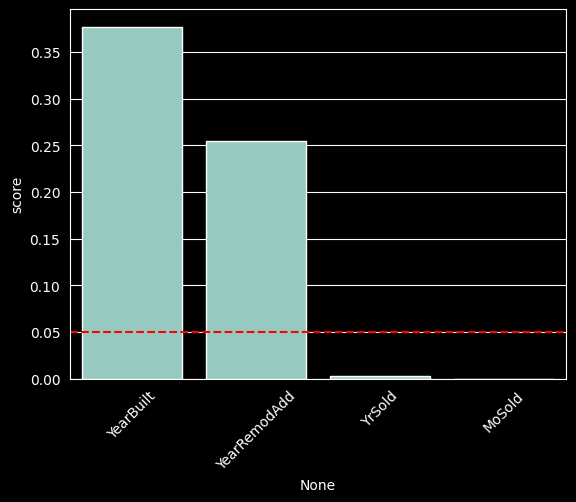

In [8]:
from sklearn.feature_selection import mutual_info_regression

X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

# Select and Save

In [9]:
final_x = data[['YearBuilt', 'SalePrice']]

final_x.to_csv('Data/time_train_selected.csv')

final_x

,YearBuilt,SalePrice
0,2003,208500
1,1976,181500
2,2001,223500
3,1915,140000
4,2000,250000
...,...,...
1407,1999,175000
1408,1978,210000
1409,1941,266500
1410,1950,142125
